In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Constants
PARAM_COUNT = 11_191_262  # Total parameter count
MB_TO_BITS = 1024**2 * 8  # Conversion factor from MB to bits

# Data directories
auc_acc_loss_dir = Path("auc_acc_loss")
broadcast_dir = Path("broadcast")


In [20]:
def preprocess_tensor_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert tensor format columns to numeric values.
    Handles both 'tensor(value)' and numeric formats.
    """
    df_processed = df.copy()

    # Define columns that might contain tensor values
    tensor_columns = ['train_auc', 'val_auc', 'train_acc', 'val_acc']

    for col in tensor_columns:
        if col in df_processed.columns:
            # Convert tensor format to numeric
            df_processed[col] = df_processed[col].astype(str).apply(
                lambda x: float(re.findall(r'[\d\.]+', x)[0]) if 'tensor' in x else float(x)
            )

    return df_processed

def calculate_bit_rate(mbytes_received: float, param_count: int = PARAM_COUNT) -> float:
    """Calculate bit rate from mbytes received."""
    return (mbytes_received * MB_TO_BITS) / param_count

def load_and_process_auc_data() -> Dict[str, pd.DataFrame]:
    """Load and process all AUC/accuracy/loss data."""
    auc_data = {}

    for file_path in auc_acc_loss_dir.glob("*_auc.csv"):
        experiment_name = file_path.stem.replace("_auc", "")
        df = pd.read_csv(file_path)
        df_processed = preprocess_tensor_columns(df)
        auc_data[experiment_name] = df_processed
        print(f"Loaded AUC data for {experiment_name}: {len(df_processed)} rows")

    return auc_data

def load_and_process_broadcast_data() -> Dict[str, pd.DataFrame]:
    """Load and process all broadcast data with worker averaging."""
    broadcast_data = {}

    for file_path in broadcast_dir.glob("*_wz.csv"):
        experiment_name = file_path.stem.replace("_wz", "")
        df = pd.read_csv(file_path)

        # Handle None values and convert to numeric
        numeric_cols = ['mbytes_recived', 'mse', 'mape%', 'mae']
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        # Group by round_id and calculate mean across workers (agent_id)
        df_averaged = df.groupby('round_id')[numeric_cols].mean().reset_index()

        # Calculate bit rate
        if 'mbytes_recived' in df_averaged.columns:
            df_averaged['bit_rate'] = df_averaged['mbytes_recived'].apply(calculate_bit_rate)

        broadcast_data[experiment_name] = df_averaged
        print(f"Loaded broadcast data for {experiment_name}: {len(df_averaged)} rounds")

    return broadcast_data


In [21]:
# Load all data
print("Loading and processing data...")
auc_data = load_and_process_auc_data()
broadcast_data = load_and_process_broadcast_data()

# Display summary statistics
print("\n=== SUMMARY STATISTICS ===")
for exp_name in auc_data.keys():
    print(f"\n{exp_name.upper()} EXPERIMENT:")
    if exp_name in auc_data:
        auc_df = auc_data[exp_name]
        print(f"  AUC Data: {len(auc_df)} rounds")
        if 'val_auc' in auc_df.columns:
            print(f"  Final Val AUC: {auc_df['val_auc'].iloc[-1]:.4f}")
        if 'val_acc' in auc_df.columns:
            print(f"  Final Val Acc: {auc_df['val_acc'].iloc[-1]:.4f}")

    if exp_name in broadcast_data:
        bc_df = broadcast_data[exp_name]
        print(f"  Broadcast Data: {len(bc_df)} rounds")
        if 'bit_rate' in bc_df.columns:
            print(f"  Avg Bit Rate: {bc_df['bit_rate'].mean():.2f}")
        if 'mape%' in bc_df.columns:
            print(f"  Avg MAPE%: {bc_df['mape%'].mean():.4f}")


Loading and processing data...
Loaded AUC data for allout: 51 rows
Loaded AUC data for hybrid1bit: 51 rows
Loaded broadcast data for allout: 50 rounds
Loaded broadcast data for hybrid1bit: 50 rounds

=== SUMMARY STATISTICS ===

ALLOUT EXPERIMENT:
  AUC Data: 51 rounds
  Final Val AUC: 0.9560
  Broadcast Data: 50 rounds
  Avg Bit Rate: 1.61
  Avg MAPE%: 33.8715

HYBRID1BIT EXPERIMENT:
  AUC Data: 51 rounds
  Final Val AUC: 0.9581
  Broadcast Data: 50 rounds
  Avg Bit Rate: 0.71
  Avg MAPE%: 40.1472


In [22]:
def plot_validation_accuracy_vs_bitrate():
    """Create twin Y-axes plot: Validation Accuracy vs Bit Rate over communication rounds."""
    
    fig, ax1 = plt.subplots(figsize=(12, 8))
    
    # Define more distinguishable markers for experiments
    markers = ['o', 's', '^', 'D', 'v', 'X', 'P', '*', 'h', '+']
    
    ax2 = ax1.twinx()
    
    # Colors matching axis labels
    acc_color = 'blue'      # For validation accuracy (left axis)
    bitrate_color = 'red'   # For bit rate (right axis)
    
    for i, (exp_name, auc_df) in enumerate(auc_data.items()):
        marker = markers[i % len(markers)]
        
        # Plot validation accuracy on left y-axis (blue color family)
        if 'val_acc' in auc_df.columns:
            ax1.plot(auc_df['round_id'], auc_df['val_acc'], 
                    color=acc_color, marker=marker, markersize=8, linewidth=2,
                    label=f'{exp_name} - Val Acc', alpha=0.8, 
                    markeredgewidth=0)
        
        # Plot bit rate on right y-axis if broadcast data exists (red color family)
        if exp_name in broadcast_data:
            bc_df = broadcast_data[exp_name]
            if 'bit_rate' in bc_df.columns:
                ax2.plot(bc_df['round_id'], bc_df['bit_rate'], 
                        color=bitrate_color, marker=marker, markersize=8, linewidth=2, 
                        linestyle='--', label=f'{exp_name} - Bit Rate', alpha=0.8,
                        markeredgewidth=0)
    
    # Formatting
    ax1.set_xlabel('Communication Round', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold', color=acc_color)
    ax2.set_ylabel('Bit Rate', fontsize=12, fontweight='bold', color=bitrate_color)

    ax1.tick_params(axis='y', labelcolor=acc_color)
    ax2.tick_params(axis='y', labelcolor=bitrate_color)
    
    # Set bit rate range
    ax2.set_ylim(0, 3.1)

    # Legends - place inside the plot
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.9)

    plt.title('Validation Accuracy vs Bit Rate Over Communication Rounds',
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_validation_auc_vs_mape():
    """Create twin Y-axes plot: Validation AUC vs MAPE% over communication rounds."""
    
    fig, ax1 = plt.subplots(figsize=(12, 8))
    
    # Define more distinguishable markers for experiments
    markers = ['o', 's', '^', 'D', 'v', 'X', 'P', '*', 'h', '+']
    
    ax2 = ax1.twinx()
    
    # Colors matching axis labels
    auc_color = 'green'     # For validation AUC (left axis)
    mape_color = 'orange'   # For MAPE% (right axis)
    
    for i, (exp_name, auc_df) in enumerate(auc_data.items()):
        marker = markers[i % len(markers)]
        
        # Plot validation AUC on left y-axis (green color family)
        if 'val_auc' in auc_df.columns:
            ax1.plot(auc_df['round_id'], auc_df['val_auc'], 
                    color=auc_color, marker=marker, markersize=8, linewidth=2,
                    label=f'{exp_name} - Val AUC', alpha=0.8, 
                    markeredgewidth=0)
        
        # Plot MAPE% on right y-axis if broadcast data exists (orange color family)
        if exp_name in broadcast_data:
            bc_df = broadcast_data[exp_name]
            if 'mape%' in bc_df.columns:
                ax2.plot(bc_df['round_id'], bc_df['mape%'], 
                        color=mape_color, marker=marker, markersize=8, linewidth=2, 
                        linestyle='--', label=f'{exp_name} - MAPE%', alpha=0.8,
                        markeredgewidth=0)
    
    # Formatting
    ax1.set_xlabel('Communication Round', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Validation AUC', fontsize=12, fontweight='bold', color=auc_color)
    ax2.set_ylabel('MAPE%', fontsize=12, fontweight='bold', color=mape_color)

    ax1.tick_params(axis='y', labelcolor=auc_color)
    ax2.tick_params(axis='y', labelcolor=mape_color)

    # Legends - place inside the plot
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.9)

    plt.title('Validation AUC vs MAPE% Over Communication Rounds',
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_rate_distortion_scatter():
    """Create separate scatter plots for each experiment: Bit Rate vs MAPE%."""
    
    # Calculate number of subplots needed
    n_experiments = len(broadcast_data)
    if n_experiments == 0:
        print("No broadcast data available for rate-distortion plots.")
        return
    
    # Create subplots
    n_cols = min(2, n_experiments)
    n_rows = (n_experiments + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    if n_experiments == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    
    # Flatten axes for easy iteration
    axes_flat = axes.flatten() if n_experiments > 1 else axes
    
    # More distinguishable markers for experiments
    markers = ['o', 's', '^', 'D', 'v', 'X', 'P', '*', 'h', '+']
    
    for i, (exp_name, bc_df) in enumerate(broadcast_data.items()):
        ax = axes_flat[i]
        marker = markers[i % len(markers)]
        
        if 'bit_rate' in bc_df.columns and 'mape%' in bc_df.columns:
            # Create scatter plot with color-coded rounds using the same marker per experiment
            scatter = ax.scatter(bc_df['bit_rate'], bc_df['mape%'], 
                               c=bc_df['round_id'], cmap='viridis', 
                               s=80, alpha=0.8, linewidths=0,
                               marker=marker)
            
            # Add colorbar
            cbar = plt.colorbar(scatter, ax=ax)
            cbar.set_label('Communication Round', fontsize=10)
            
            ax.set_xlabel('Bit Rate', fontsize=12, fontweight='bold')
            ax.set_ylabel('MAPE%', fontsize=12, fontweight='bold')
            ax.set_title(f'{exp_name.title()} Protocol\nRate-Distortion', 
                        fontsize=12, fontweight='bold')
            
            # Set bit rate range
            ax.set_xlim(0, 3.1)
            
            # Set logarithmic y-axis for MAPE%
            ax.set_yscale('log')
            
            ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for j in range(n_experiments, len(axes_flat)):
        axes_flat[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()



Generating plots...
1. Creating Validation Accuracy vs Bit Rate plot...


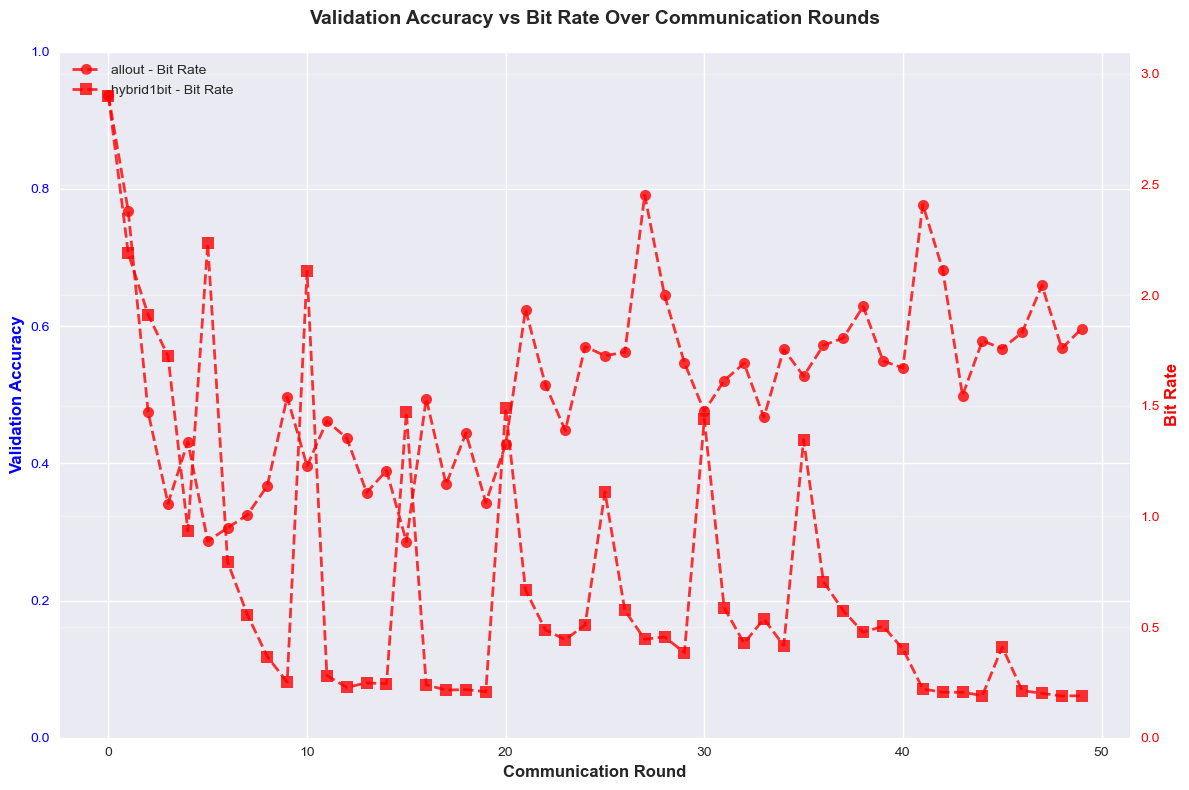

2. Creating Validation AUC vs MAPE% plot...


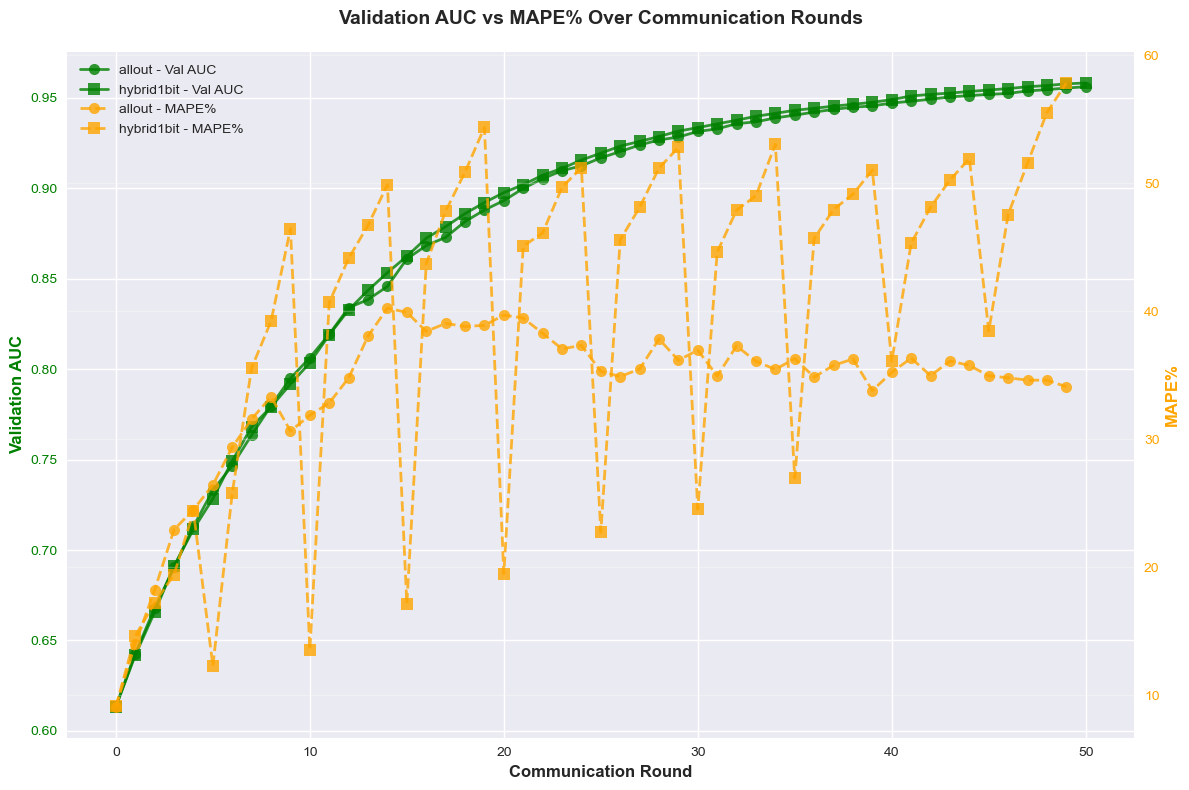

3. Creating Rate-Distortion scatter plots...


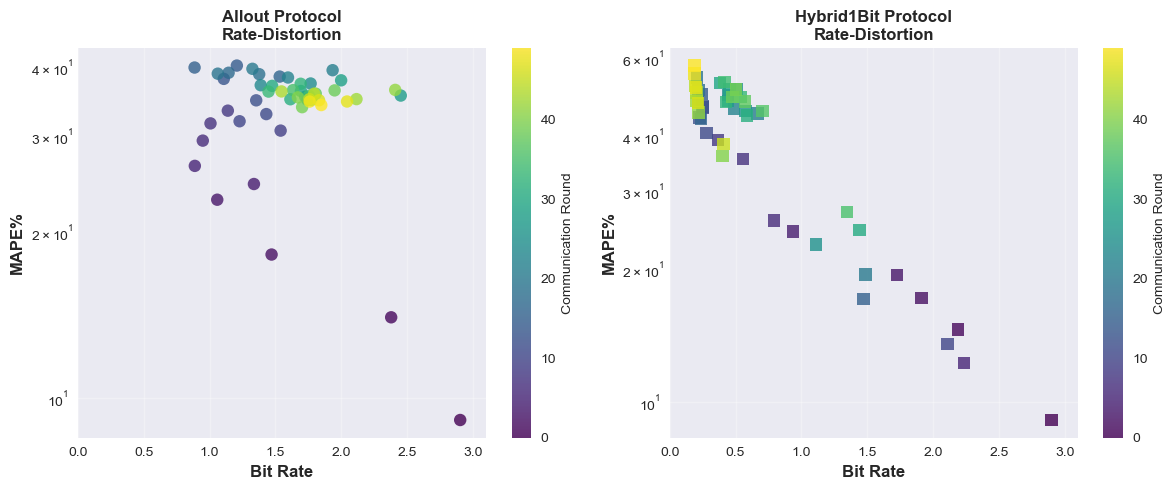


All plots generated successfully!


In [23]:
# Generate all plots
print("\nGenerating plots...")

print("1. Creating Validation Accuracy vs Bit Rate plot...")
plot_validation_accuracy_vs_bitrate()

print("2. Creating Validation AUC vs MAPE% plot...")
plot_validation_auc_vs_mape()

print("3. Creating Rate-Distortion scatter plots...")
plot_rate_distortion_scatter()

print("\nAll plots generated successfully!")


In [24]:
# Additional utility functions for future analysis

def compare_final_metrics():
    """Compare final metrics across all experiments."""

    comparison_data = []

    for exp_name in set(list(auc_data.keys()) + list(broadcast_data.keys())):
        row = {'experiment': exp_name}

        # Get final AUC/accuracy metrics
        if exp_name in auc_data:
            auc_df = auc_data[exp_name]
            if len(auc_df) > 0:
                final_row = auc_df.iloc[-1]
                row['final_val_auc'] = final_row.get('val_auc', np.nan)
                row['final_val_acc'] = final_row.get('val_acc', np.nan)
                row['final_train_loss'] = final_row.get('train_loss', np.nan)

        # Get average communication metrics
        if exp_name in broadcast_data:
            bc_df = broadcast_data[exp_name]
            if len(bc_df) > 0:
                row['avg_bit_rate'] = bc_df['bit_rate'].mean() if 'bit_rate' in bc_df.columns else np.nan
                row['avg_mape'] = bc_df['mape%'].mean() if 'mape%' in bc_df.columns else np.nan
                row['final_mape'] = bc_df['mape%'].iloc[-1] if 'mape%' in bc_df.columns else np.nan

        comparison_data.append(row)

    comparison_df = pd.DataFrame(comparison_data)
    print("\n=== FINAL METRICS COMPARISON ===")
    print(comparison_df.to_string(index=False, float_format='%.4f'))

    return comparison_df

def save_processed_data():
    """Save processed data for future use."""

    # Create output directory
    output_dir = Path("processed_data")
    output_dir.mkdir(exist_ok=True)

    # Save AUC data
    for exp_name, df in auc_data.items():
        df.to_csv(output_dir / f"{exp_name}_processed_auc.csv", index=False)

    # Save broadcast data
    for exp_name, df in broadcast_data.items():
        df.to_csv(output_dir / f"{exp_name}_processed_broadcast.csv", index=False)

    print(f"\nProcessed data saved to {output_dir}")

# Run comparison
comparison_df = compare_final_metrics()

print("\n=== SCRIPT COMPLETION ===")
print("✓ Data preprocessing with tensor format handling")
print("✓ Worker averaging for broadcast data")
print("✓ Bit rate calculations")
print("✓ Validation Accuracy vs Bit Rate plot")
print("✓ Validation AUC vs MAPE% plot")
print("✓ Rate-Distortion scatter plots")
print("✓ Summary statistics and final metrics comparison")
print("\nScript ready for additional experiments - just add new CSV files to the folders!")



=== FINAL METRICS COMPARISON ===
experiment  final_val_auc  final_val_acc  final_train_loss  avg_bit_rate  avg_mape  final_mape
hybrid1bit         0.9581            NaN            0.7096        0.7065   40.1472     57.8312
    allout         0.9560            NaN            0.7370        1.6052   33.8715     34.1000

=== SCRIPT COMPLETION ===
✓ Data preprocessing with tensor format handling
✓ Worker averaging for broadcast data
✓ Bit rate calculations
✓ Validation Accuracy vs Bit Rate plot
✓ Validation AUC vs MAPE% plot
✓ Rate-Distortion scatter plots
✓ Summary statistics and final metrics comparison

Script ready for additional experiments - just add new CSV files to the folders!
